In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({'savefig.dpi':300, 'axes.labelweight':'normal'})
matplotlib.rcParams['axes.linewidth'] = 0.8
from matplotlib import rc
preamble = r'''
\usepackage{physics} \usepackage{mhchem}'''
plt.rc('text.latex', preamble=preamble)
rc('text', usetex=True)

import os 
import seaborn as sns

from takarada_funkcije import *

In [2]:
parameters1 = {'n_pass' : 1e-3,
'epsilon_threshold' : 1e-4,
'N_epsilon' : 5,
'maxiter' : 50,
'eps_last' : 1e-4,
'dmu' : 0.1,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 5,
'eps0' : 0.03,
}

parameters2 = {'n_pass' : 1e-3,
'epsilon_threshold' : 1e-4,
'N_epsilon' : 5,
'maxiter' : 20,
'eps_last' : 1e-4,
'dmu' : 0.1,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 5,
'eps0' : 0.03,
}

Nk = 200

In [ ]:
# example (c)
a = 1
b = 0
t = 3
t_ = 1
t12 = 0.
epsilon = 4.1
Vb = 0
Vc = 0

phys_parameters = {'b': b,
                   't': t,
                    't_': t_,
                    't12': t12,
                    'epsilon': epsilon,
                    'Vb': Vb,
                    'Vc': Vc}

scale = 1.03
beta0 = 230
betas = np.hstack([np.linspace(30,220)[::-1], np.linspace(15,30,15)[::-1]])
Ts = 1/np.array(betas)
ends = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]

Gamma = 0.01
eps = 1e-9
Nomega = 150

collect = np.zeros((3, len(Ts)))

mu0 = 0.
include_hartree = False
mu0 = find_GS_mu(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()


for i, T in enumerate(Ts):
    m.reset(mu0)
    set_betas = beta0/scale**np.arange(ends[i])
    set_Ts = 1/set_betas
    m.run(set_Ts, Gamma)

    omega_max = np.sqrt(np.abs(np.arccosh(1/(4*eps*4*T)))) * 2 * T
    omegas = np.linspace(-omega_max, omega_max, Nomega)

    rez = Phit(m.K, m.rho, m.vecs, m.energije, phys_parameters, m.mu, omegas, Gamma)
    
    K0 = np.sum(-fd_1(omegas, m.Ts[-1]) * rez['phi'].real)
    K1_a = np.sum(-fd_1(omegas, m.Ts[-1]) * rez['phiK'].real)
    K1_b = np.sum(-fd_1(omegas, m.Ts[-1]) * rez['phi'].real * omegas)
    
    K0_boltz, K1_boltz = Kn_boltz(m.K, m.energije, m.mu, m.Ts[-1])

    collect[0,i] = - K1_a/(K0 * T)
    collect[1,i] = -K1_b/(K0*T)
    collect[2,i] = -K1_boltz/(K0_boltz*T)

    print(f'calculated S at T={T}')


found mu in the Ground state


In [ ]:

for i, T in enumerate(Ts):
    m.reset(mu0)
    set_betas = beta0/scale**np.arange(ends[i])
    set_Ts = 1/set_betas
    m.run(set_Ts, Gamma)

    omega_max = np.sqrt(np.abs(np.arccosh(1/(4*eps*4*T)))) * 2 * T
    omegas = np.linspace

    


In [ ]:
phys_parameters0 = {'b': b,
                   't': t,
                    't_': t_,
                    't12': 0,
                    'epsilon': epsilon,
                    'Vb': 0,
                    'Vc': 0}
mu0_0 = 0.
include_hartree = False
mu0_0 = find_GS_mu(Nk, mu0_0 , phys_parameters0, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m0 = model(Nk, mu0_0,  phys_parameters0, parameters1, parameters2, include_hartree)
m0.GS()


plt.plot(m.K, m.energije[0] - m.mu, color='red', label='EI faza, numericno')
plt.plot(m.K, m.energije[1] - m.mu, color='red')

plt.plot(m.K, m0.energije[0] - m0.mu, color='0', label='normalna faza')
plt.plot(m.K, m0.energije[1] - m0.mu, color='0')

plt.title('d', fontsize=30)
plt.ylim(-2,6)
plt.xlim(-2,2)

energije_analytic = E_analytic(m.K, m.rho, phys_parameters)
plt.plot(m.K, energije_analytic[0] - m.mu, ls='dotted', lw=3, color='cyan', label='EI faza, analiticno')
plt.plot(m.K, energije_analytic[1] - m.mu, ls='dotted', lw=3, color='cyan')

plt.legend(fontsize=12)
plt.xlabel('moment', fontsize=12)
plt.ylabel('energija - kem. potencial', fontsize=12)

plt.show()
m.phi

In [11]:

Gamma = 0.05
omegas = np.linspace(-2,2,100)


j, jK, jI = j_tok(m.K, phys_parameters, m.mu)
print(np.allclose(jI,0))
M_4 = - np.einsum('ijlkq, jlk-> ijkq', jI, m.rho)
phi4 = np.zeros((len(omegas), Nk, Nk), dtype='complex')
for i, omega in enumerate(omegas):
    for ii, _ in enumerate(m.K):
        for iii, _ in enumerate(m.K):
            ind = (ii + iii - Nk//2) % Nk
            u = m.vecs[:,:,ind]
            A = spektralna_k(omega, m.mu, m.energije[:,ind], Gamma=Gamma)
            phi4[i, ii, iii] += np.trace(u @ M_4[:,:,ii,iii] @ u.conj().T @ A @ u @ j[:,:,ind] @ u.conj().T @ A)

False


<Axes: >

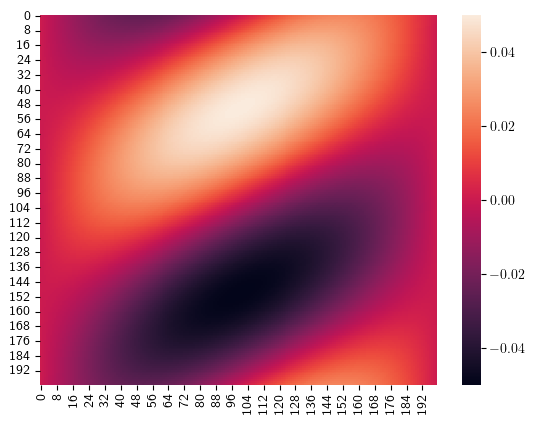

In [15]:

j, jK, jI = j_tok(m.K, phys_parameters, m.mu)
sns.heatmap(jI[0,1,0].real)


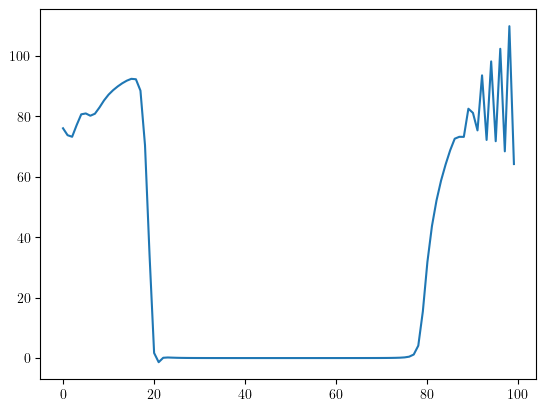

In [16]:
plt.plot(np.einsum('ukq->u', phi4.real))

/var/folders/pm/d_9cvb8n3xlftb1wrgw8y4dr0000gq/T/ipykernel_15961/2683976935.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


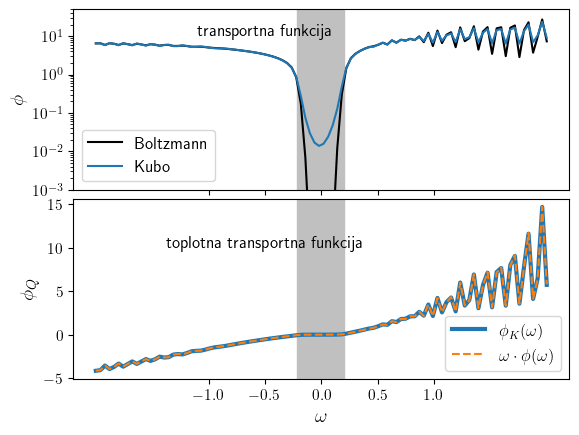

In [142]:

Gamma = 0.05
omegas = np.linspace(-2,2,100)
rez0 = Phit(m0.K, m0.rho, m0.vecs, m0.energije, phys_parameters0, m0.mu, omegas, Gamma)

phi_boltz0 = Phi_boltz(m0.K, m0.rho, phys_parameters0, m0.energije, m0.mu, omegas, faktor=0.3)

fig = plt.figure()
gs = fig.add_gridspec(2, hspace=0.05)
ax = gs.subplots(sharex=True)

ax[0].set_xticks([])
ax[0].plot(omegas, phi_boltz0 / (2*Gamma), label='Boltzmann', c='0')
ax[0].plot(omegas, np.pi * rez0['phi'].real, label='Kubo')
ax[0].legend(fontsize=12)
ax[0].text(-0.5, 10, 'transportna funkcija', ha='center', fontsize=12)
ax[0].set_ylabel(r'$\phi$', fontsize=14)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-3,50)

for j in range(2):
    plt.setp(ax[j].get_yticklabels(), fontsize=11)
    ax[j].axvspan(np.max(m0.energije[0]) - m.mu, np.min(m0.energije[1]) - m0.mu, color='silver', zorder=-100)
ax[1].text(-0.5, 10, 'toplotna transportna funkcija', ha='center', fontsize=12)
ax[1].plot(omegas, rez0['phiK'].real, lw=3, label=r'$\phi_K(\omega)$')
ax[1].plot(omegas, omegas * rez0['phi'].real, ls='dashed', label=r'$ \omega \cdot \phi(\omega)$')
ax[1].legend(fontsize=12)
ax[1].set_xticks(0.5*np.arange(-2,3))
ax[1].set_ylabel(r'$\phi_Q$', fontsize=14)

plt.setp(ax[1].get_xticklabels(), fontsize=11)
ax[1].set_xlabel(r'$\omega$', fontsize=14)
plt.tight_layout()
os.chdir('/Users/ana/Desktop/takarada/slike')
plt.savefig('neinteragirajoci.png')
plt.show()


(-1.8, 2.2)

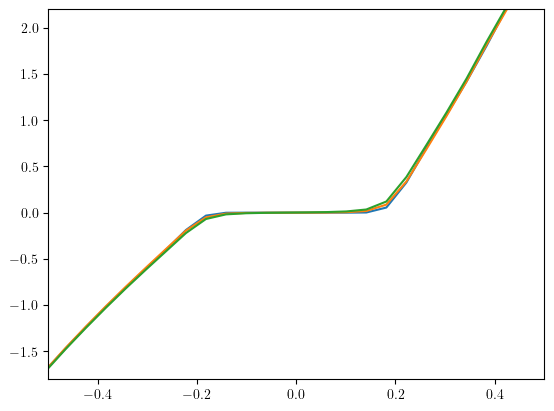

In [143]:
plt.plot(omegas, omegas * phi_boltz0 / (2*Gamma))
plt.plot(omegas, omegas * rez0['phi'].real * np.pi)
plt.plot(omegas, rez0['phiK'].real * np.pi)
plt.xlim(-0.5,0.5)
plt.ylim(-1.8,2.2)

In [144]:
# interagirajoci
omegas = np.linspace(-2,2,100)
rez = Phit(m.K, m.rho, m.vecs, m.energije, phys_parameters, m.mu, omegas, Gamma)
phi_boltz = Phi_boltz(m.K, m.rho, phys_parameters, m.energije, m.mu, omegas, faktor=0.3)

/var/folders/pm/d_9cvb8n3xlftb1wrgw8y4dr0000gq/T/ipykernel_15961/1219638190.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


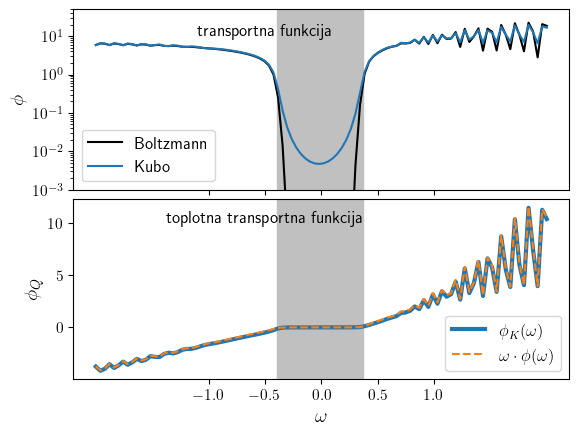

In [145]:
fig = plt.figure()
gs = fig.add_gridspec(2, hspace=0.05)
ax = gs.subplots(sharex=True)

ax[0].set_xticks([])
ax[0].plot(omegas, phi_boltz / (2*Gamma), label='Boltzmann', c='0')
ax[0].plot(omegas, np.pi * rez['phi'].real, label='Kubo')
ax[0].legend(fontsize=12)
ax[0].text(-0.5, 10, 'transportna funkcija', ha='center', fontsize=12)
ax[0].set_ylabel(r'$\phi$', fontsize=14)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-3,50)

for j in range(2):
    plt.setp(ax[j].get_yticklabels(), fontsize=11)
    ax[j].axvspan(np.max(m.energije[0]) - m.mu, np.min(m.energije[1]) - m.mu, color='silver', zorder=-100)
ax[1].text(-0.5, 10, 'toplotna transportna funkcija', ha='center', fontsize=12)
ax[1].plot(omegas, rez['phiK'].real, lw=3, label=r'$\phi_K(\omega)$')
ax[1].plot(omegas, omegas * rez['phi'].real, ls='dashed', label=r'$ \omega \cdot \phi(\omega)$')
ax[1].legend(fontsize=12)
ax[1].set_xticks(0.5*np.arange(-2,3))
ax[1].set_ylabel(r'$\phi_Q$', fontsize=14)

plt.setp(ax[1].get_xticklabels(), fontsize=11)
ax[1].set_xlabel(r'$\omega$', fontsize=14)
plt.tight_layout()
plt.show()

(-0.5, 0.5)

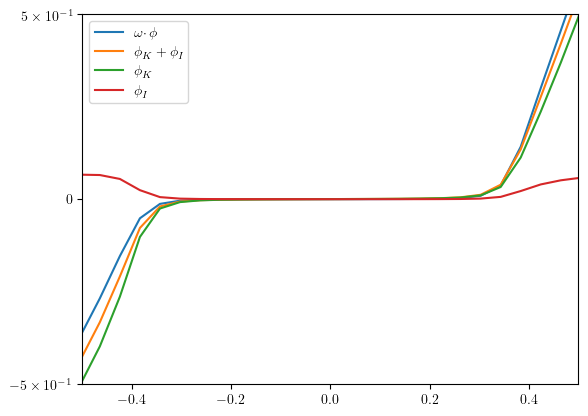

In [170]:
plt.plot(omegas, omegas * rez['phi'], label=r'$\omega\cdotp\phi$',)
plt.plot(omegas, rez['phiK'] + rez['phi4'], label=r'$\phi_K + \phi_I$')
plt.plot(omegas, rez['phiK'], label=r'$\phi_K$')

plt.plot(omegas, rez['phi4'], label=r'$\phi_I$')
plt.legend()

plt.yscale('symlog')
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)

(-1.6, 1.7)

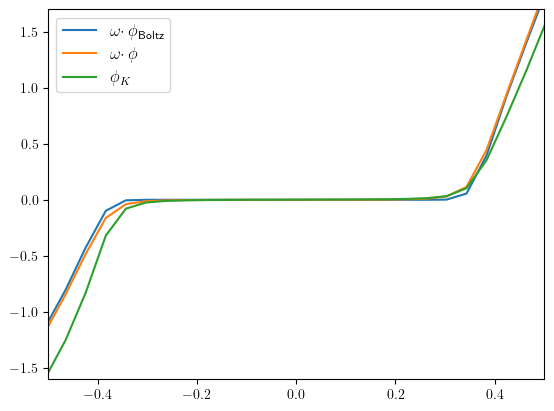

In [146]:
plt.plot(omegas, omegas * phi_boltz / (2*Gamma), label=r'$\omega \cdotp \phi_{\text{Boltz}}$')
plt.plot(omegas, omegas * rez['phi'].real * np.pi, label=r'$\omega\cdotp \phi$')
plt.plot(omegas, rez['phiK'].real * np.pi, label=r'$\phi_K$')
plt.legend(fontsize=12)
plt.xlim(-0.5,0.5)
plt.ylim(-1.6,1.7)

found mu in the Ground state
found mu in the Ground state


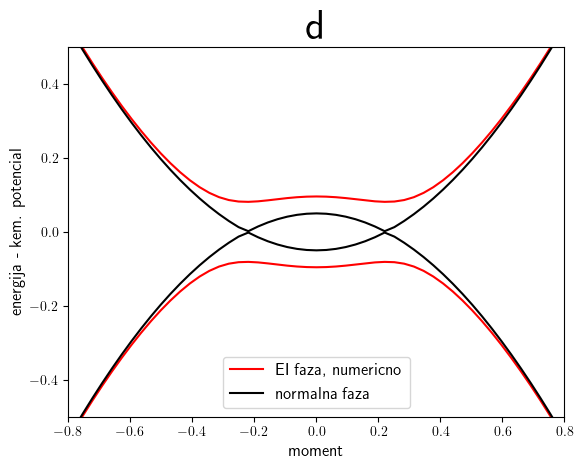

[np.float64(0.08169117748699074), np.float64(0.06262189343140329)]

In [132]:
# example (c)
a = 1
b = a/2
t = 1
t_ = 1.*t
t12 = 0
epsilon = 1.95*t
Vb = 0.5*t
Vc = 0.5*t

phys_parameters = {'b': b,
                   't': t,
                    't_': t_,
                    't12': t12,
                    'epsilon': epsilon,
                    'Vb': Vb,
                    'Vc': Vc}

mu0 = 0.
include_hartree = False
mu0 = find_GS_mu(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()

phys_parameters0 = {'b': b,
                   't': t,
                    't_': t_,
                    't12': 0,
                    'epsilon': epsilon,
                    'Vb': 0,
                    'Vc': 0}
mu0_0 = 0.
include_hartree = False
mu0_0 = find_GS_mu(Nk, mu0_0 , phys_parameters0, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m0 = model(Nk, mu0_0,  phys_parameters0, parameters1, parameters2, include_hartree)
m0.GS()


plt.plot(m.K, m.energije[0] - m.mu, color='red', label='EI faza, numericno')
plt.plot(m.K, m.energije[1] - m.mu, color='red')

plt.plot(m.K, m0.energije[0] - m0.mu, color='0', label='normalna faza')
plt.plot(m.K, m0.energije[1] - m0.mu, color='0')

plt.title('d', fontsize=30)
plt.ylim(-0.5,0.5)
plt.xlim(-0.8,.8)

plt.legend(fontsize=12)
plt.xlabel('moment', fontsize=12)
plt.ylabel('energija - kem. potencial', fontsize=12)

plt.show()
m.phi

In [133]:
# interagirajoci
omegas = np.linspace(-1,1,100)
rez = Phit(m.K, m.rho, m.vecs, m.energije, phys_parameters, m.mu, omegas, Gamma)
phi_boltz = Phi_boltz(m.K, m.rho, phys_parameters, m.energije, m.mu, omegas, faktor=0.3)

array([-7.30577126e-20, -1.59798766e-19, -2.24269807e-19, -3.04363424e-19,
       -3.11915626e-19, -3.08056574e-19, -2.93909831e-19, -1.76498555e-19,
       -7.32750771e-20, -9.06549005e-20, -2.24063952e-19, -3.19431991e-19,
       -2.26974049e-19, -8.82628447e-20, -2.00357715e-20, -3.14154028e-21,
       -2.85221387e-20, -1.17079307e-19, -2.11981522e-19, -2.03810872e-19,
       -1.44084850e-19, -1.00195691e-19, -6.13255114e-20, -3.47049762e-20,
       -1.44371659e-20, -2.75473357e-20, -7.99092084e-20, -1.07417691e-19,
       -5.37607910e-20, -4.94840333e-20, -2.17248526e-19, -3.86305426e-19,
       -4.37946502e-19, -4.69277120e-19, -5.05237022e-19, -4.99268100e-19,
       -4.31230116e-19, -3.24926542e-19, -3.32327643e-19, -3.39382283e-19,
       -1.67359470e-19,  9.54632927e-20, -1.16244408e-19, -4.31707354e-19,
       -5.73161642e-19, -2.93580258e-19, -2.61238317e-19, -1.68536929e-19,
       -6.63808753e-20,  6.79177095e-20,  8.95528513e-20, -2.10877582e-20,
        1.69116550e-19,  

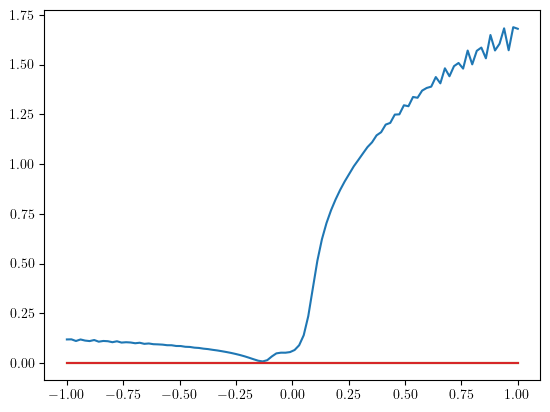

In [140]:
plt.plot(omegas, rez['phi3'].real)
plt.plot(omegas, rez['phi4'].real)
plt.plot(omegas, rez['phi5'].real)
plt.plot(omegas, rez['phi6'].real)

rez['phi6'].real

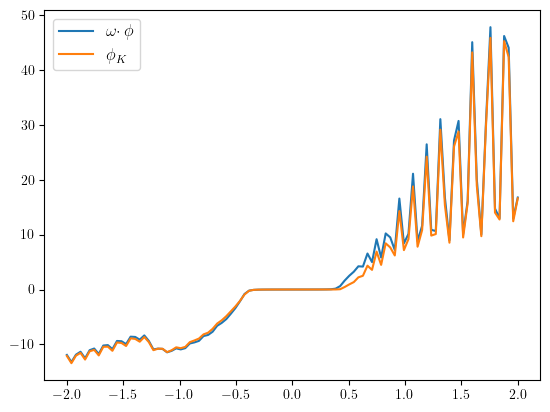

In [103]:
plt.plot(omegas, omegas * rez['phi'].real * np.pi, label=r'$\omega\cdotp \phi$')
plt.plot(omegas, rez['phiK'].real * np.pi + rez['phi3'].real * np.pi, label=r'$\phi_K$')

plt.legend(fontsize=12)


In [ ]:
# example (c)
a = 1
b = a/2
t = 1
t_ = 3.*t
t12 = 0
epsilon = 4.2*t
Vb = 2*t
Vc = 2*t

phys_parameters = {'b': b,
                   't': t,
                    't_': t_,
                    't12': t12,
                    'epsilon': epsilon,
                    'Vb': Vb,
                    'Vc': Vc}

mu0 = 0.
include_hartree = False
mu0 = find_GS_mu(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()

phys_parameters0 = {'b': b,
                   't': t,
                    't_': t_,
                    't12': 0,
                    'epsilon': epsilon,
                    'Vb': 0,
                    'Vc': 0}
mu0_0 = 0.
include_hartree = False
mu0_0 = find_GS_mu(Nk, mu0_0 , phys_parameters0, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m0 = model(Nk, mu0_0,  phys_parameters0, parameters1, parameters2, include_hartree)
m0.GS()


plt.plot(m.K, m.energije[0] - m.mu, color='red', label='EI faza, numericno')
plt.plot(m.K, m.energije[1] - m.mu, color='red')

plt.plot(m.K, m0.energije[0] - m0.mu, color='0', label='normalna faza')
plt.plot(m.K, m0.energije[1] - m0.mu, color='0')

plt.title('d', fontsize=30)
plt.ylim(-2,6)
plt.xlim(-2,2)

prvi in drugi prispevek sta enaka nic: True
tretji prispevek je enak nic: False


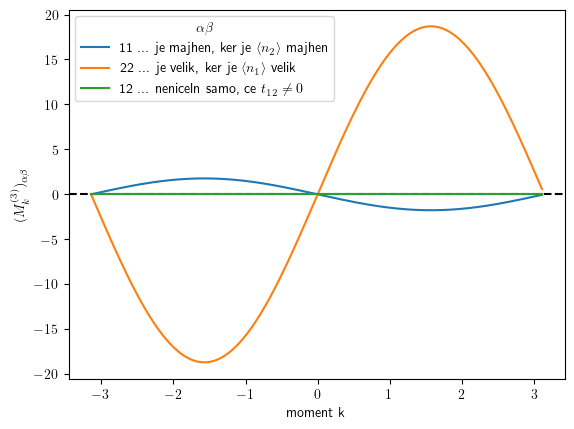

cetrti prispevek je enak nic: False
peti prispevek je enak nic: True


In [199]:
j, jK, jI = j_tok(m.K, phys_parameters, m.mu)
U = m.vecs
rho = m.rho

# prvi in drugi prispevek sta enaka nic, saj velja:
print(f'prvi in drugi prispevek sta enaka nic: {np.allclose(np.einsum('ijk,ijk->', j, rho), 0)}')

# tretji prispevek
M_3 = np.einsum('acbk, ccu-> abk', jI[:,:,:,:,m.Nk//2], rho)
print(f'tretji prispevek je enak nic: {np.allclose(M_3, 0)}')
plt.plot(m.K, M_3[0,0].real, label=r'11 ... je majhen, ker je $\expval{n_2}$ majhen')
plt.plot(m.K, M_3[1,1].real, label=r'22 ... je velik, ker je $\expval{n_1}$ velik')
plt.plot(m.K, M_3[0,1].real, label=r'12 ... neniceln samo, ce $t_{12}\neq 0$')
plt.xlabel('moment k')
plt.ylabel(r'$(M_k^{(3)})_{\alpha\beta}$')
plt.legend().set_title(r'$\alpha\beta$')
plt.axhline(0, color='0', ls='dashed', zorder=-1000)
plt.show()

# cetrti prispevek
M_4 = - np.einsum('ijlkq, jlk->ijkq', jI, rho)

print(f'cetrti prispevek je enak nic: {np.allclose(M_4, 0)}')

# peti prispevek -> je nic
M_5 = np.diag(np.einsum('ijlk,ilk->j', jI[:,:,:,:,m.Nk//2], rho))
M_5new = np.diag(np.einsum('ijlk, mik, mlk, mmk -> j', jI[:,:,:,:,m.Nk//2], U, U.conj(), m.fs))

print(f'peti prispevek je enak nic: {np.allclose(M_5, 0)}')


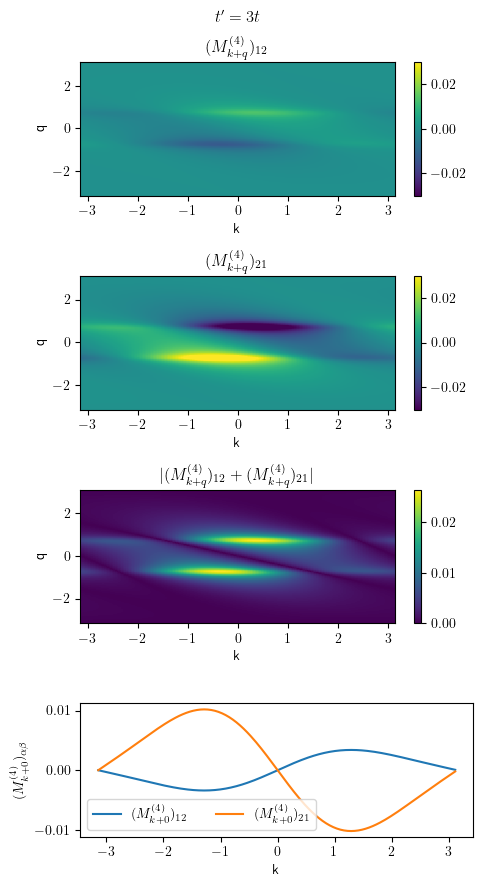

In [200]:
# cetrti prispevek
j, jK, jI = j_tok(m.K, phys_parameters, m.mu)
U = m.vecs
rho = m.rho

M_4 = - np.einsum('ijlkq, jlk-> ijkq', jI, rho)

fig, ax = plt.subplots(nrows=4, figsize=(5,9))

for ind in range(3):
    ax[ind].set_xlabel('k')
    ax[ind].set_ylabel('q')

im = ax[0].pcolormesh(m.K, m.K, M_4[0,1].real, vmin=-0.03, vmax=0.03)
fig.colorbar(im, ax=ax[0])
ax[0].set_title('$(M_{k+q}^{(4)})_{12}$')

im2 = ax[1].pcolormesh(m.K, m.K, M_4[1,0].real, vmin=-0.03, vmax=0.03)
fig.colorbar(im2, ax=ax[1])
ax[1].set_title('$(M_{k+q}^{(4)})_{21}$')

im3 = ax[2].pcolormesh(m.K, m.K, np.abs(M_4[1,0].real + M_4[0,1].real))
fig.colorbar(im3, ax=ax[2])
ax[2].set_title('$|(M_{k+q}^{(4)})_{12} + (M_{k+q}^{(4)})_{21} |$')

ax[3].plot(m.K, M_4[0,1, m.Nk//2].real, label='$(M_{k+0}^{(4)})_{12}$')
ax[3].plot(m.K, M_4[1,0, m.Nk//2].real, label='$(M_{k+0}^{(4)})_{21}$')
ax[3].legend(ncols=2)
ax[3].set_ylabel(r'$(M_{k+0}^{(4)})_{\alpha\beta}$')
ax[3].set_xlabel('k')

fig.suptitle(f"$t'=3t$")
plt.tight_layout()

In [330]:
omegas = np.linspace(-1,1,200)
Gamma = 0.05
res = Phi(m.K, m.rho, m.vecs, m.energije, phys_parameters, m.mu, omegas, Gamma)

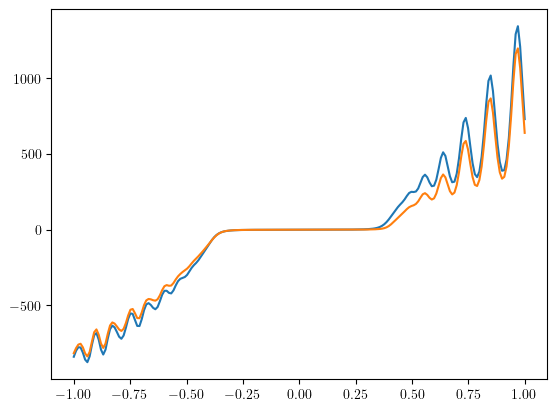

In [335]:
plt.plot(omegas, omegas * res[0].real)

plt.plot(omegas, res[1].real)


In [321]:
j, jK, jI = j_tok(m.K, phys_parameters, m.mu)
U = m.vecs
rho = m.rho

omegas = np.linspace(-1,1,200)
Gamma = 0.05

M_3 = np.einsum('acbk, ccu-> abk', jI[:,:,:,:,m.Nk//2], rho)

# koeficient L_11, kineticni prispevek in tretji interakcijski prispevek
phi = np.zeros((len(omegas), m.Nk), dtype='complex')
phiK = np.copy(phi)
phi3 = np.copy(phi)

for i, omega in enumerate(omegas):
    for ii, k in enumerate(m.K):
        u = U[:,:,ii]
        A = spektralna_k(omega, m.mu, m.energije[:,ii], Gamma=Gamma)
        phi[i, ii] += np.trace(u @ j[:,:,ii] @ u.conj().T @ A @ u @ j[:,:,ii] @ u.conj().T @ A)
        phiK[i, ii] += np.trace(u @ jK[:,:,ii] @ u.conj().T @ A @ u @ j[:,:,ii] @ u.conj().T @ A)
        phi3[i, ii] += np.trace(u @ M_3[:,:,ii] @ u.conj().T @ A @ u @ j[:,:,ii] @ u.conj().T @ A)

# cetrti prispevek
M_4 = - np.einsum('ijlkq, jlk-> ijkq', jI, rho)
phi_4 = np.zeros((len(omegas), m.Nk, m.Nk), dtype='complex')
for i, omega in enumerate(omegas):
    if i % 10 == 0: print(i)
    for ii, k in enumerate(m.K):
        for iii, k in enumerate(m.K):
            ind = (ii + iii - m.Nk//2) % m.Nk
            matrix = U[:,:,ind] @ M_4[:,:,ii,iii] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]) @ U[:,:,ind] @ j[:,:,ind] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind])
            phi_4[i, ii, iii] = np.trace(U[:,:,ind] @ M_4[:,:,ii,iii] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]) @ U[:,:,ind] @ j[:,:,ind] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]))


vel1 = np.diff(m.energije[0]) / (m.K[1] - m.K[0])
vel2 = np.diff(m.energije[1]) / (m.K[1] - m.K[0])
phi_boltz = np.zeros(len(omegas))
faktor = 0.1
v_max = np.max([np.max(np.abs(vel1)), np.max(np.abs(vel2))])
sigma = np.sqrt(v_max * (omegas[1] - omegas[0])) * faktor
for i, omega in enumerate(omegas):
    for ii, k in enumerate(m.K[1:]):
        phi_boltz[i] += 1/np.sqrt(2*np.pi*sigma**2)**0.5 * np.exp(-(omega - m.energije[0,ii] + m.mu)**2/(2*sigma**2)) * vel1[ii]**2
        phi_boltz[i] += 1/np.sqrt(2*np.pi*sigma**2)**0.5 * np.exp(-(omega - m.energije[1,ii] + m.mu)**2/(2*sigma**2)) * vel2[ii]**2

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190


In [322]:
# sesti prispevek

M_6 = np.zeros((2,2,m.Nk), dtype='complex')
for i, k in enumerate(m.K):
    for ii, q in enumerate(m.K):
        ind = (ii + iii - m.Nk//2) % m.Nk
        M_6[:,:,i] += np.einsum('ijl,ij->jl', jI[:,:,:,i,ii], rho[:,:,ind])

phi_6 = np.zeros(len(omegas), dtype='complex')
for i, omega in enumerate(omegas):
    for jj, k in enumerate(m.K):
        phi_6[i] = np.trace(U[:,:,jj] @ M_6[:,:,jj] @ U[:,:,jj].conj().T @ spektralna_k(omega, m.mu, m.energije[:,jj]) @ U[:,:,jj] @ j[:,:,jj] @ U[:,:,jj].conj().T @ spektralna_k(omega, m.mu, m.energije[:,jj]))

(-1.0, 1.0)

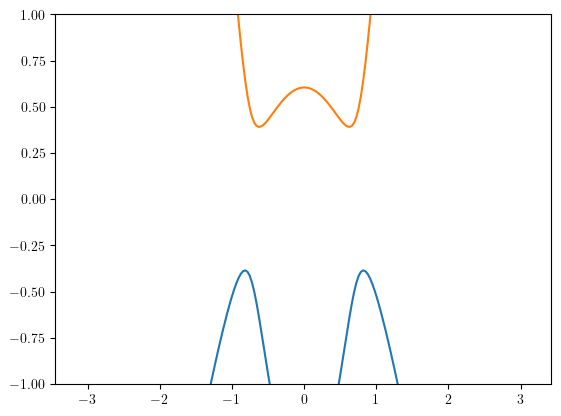

In [320]:
plt.plot(m.K, m.energije[0] - m.mu)
plt.plot(m.K, m.energije[1] - m.mu)
plt.ylim(-1,1)

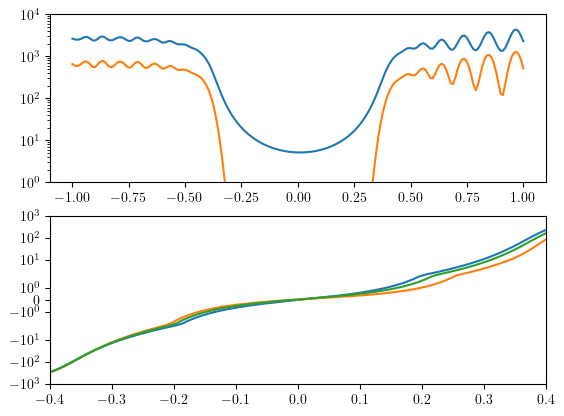

In [323]:
fig, ax = plt.subplots(nrows=2)

ax[0].plot(omegas, np.einsum('uk->u', phi).real * np.pi)
ax[0].plot(omegas, phi_boltz / (2*Gamma))
ax[0].set_ylim(1e0,1e4)
ax[0].set_yscale('log')

#ax[1].plot(omegas, omegas * phi_boltz / (2*Gamma))
ax[1].plot(omegas, omegas*np.einsum('uk->u', phi).real * np.pi)
ax[1].plot(omegas, np.einsum('uk->u', phiK).real  * np.pi )
ax[1].plot(omegas, np.einsum('uk->u', phiK).real  * np.pi + np.einsum('ukq->u', phi_4).real * np.pi  )
#ax[1].plot(omegas, np.einsum('uk->u', phi3).real  * np.pi)

plt.ylim(-1000,1000)
plt.xlim(-0.4,0.4)
ax[1].set_yscale('symlog')

cetrta transportna funkcija je enaka nic: False


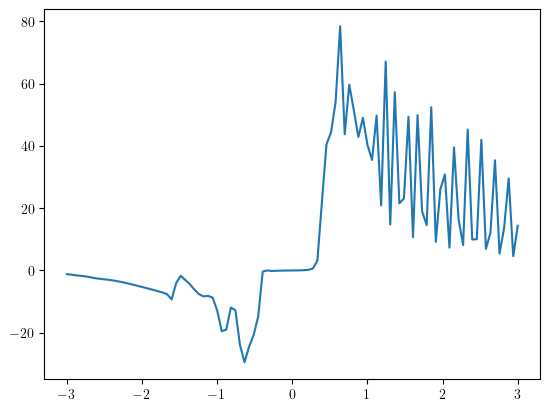

In [216]:
print(f'cetrta transportna funkcija je enaka nic: {np.allclose(np.einsum('ukq->u', phi_4), 0)}')
plt.plot(omegas, np.einsum('ukq->u', phi_4).real)

In [133]:
# cetrti prispevek
M_4 = - np.einsum('ijlkq, jlk->ijkq', jI, rho)
omegas = np.linspace(-3,3,100)

phi_4 = np.zeros((len(omegas), m.Nk, m.Nk), dtype='complex')
for i, omega in enumerate(omegas):
    print(i)
    for ii, k in enumerate(m.K):
        for iii, k in enumerate(m.K):
            ind = (ii + iii - m.Nk//2) % m.Nk
            matrix = U[:,:,ind] @ M_4[:,:,ii,iii] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]) @ U[:,:,ind] @ j[:,:,ind] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind])
            phi_4[i, ii, iii] = np.trace(U[:,:,ind] @ M_4[:,:,ii,iii] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]) @ U[:,:,ind] @ j[:,:,ind] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]))

sns.heatmap(phi_4[40].real)
plt.show()
np.einsum('ijk->i', phi_4)

# sesti prispevek
M_6 = np.zeros((2,2,m.Nk), dtype='complex')
for i, k in enumerate(m.K):
    for ii, q in enumerate(m.K):
        ind = (ii + iii - m.Nk//2) % m.Nk
        M_6[:,:,i] += np.einsum('ijl,ij->jl', jI[:,:,:,i,ii], rho[:,:,ind])

phi_6 = np.zeros(len(omegas), dtype='complex')
for i, omega in enumerate(omegas):
    for jj, k in enumerate(m.K):
        phi_6[i] = np.trace(U[:,:,jj] @ M_6[:,:,jj] @ U[:,:,jj].conj().T @ spektralna_k(omega, m.mu, m.energije[:,jj]) @ U[:,:,jj] @ j[:,:,jj] @ U[:,:,jj].conj().T @ spektralna_k(omega, m.mu, m.energije[:,jj]))
        

0
1
2
3
4


KeyboardInterrupt: 

found mu in the Ground state
found mu in the Ground state


Text(0, 0.5, 'energija - kem. potencial')

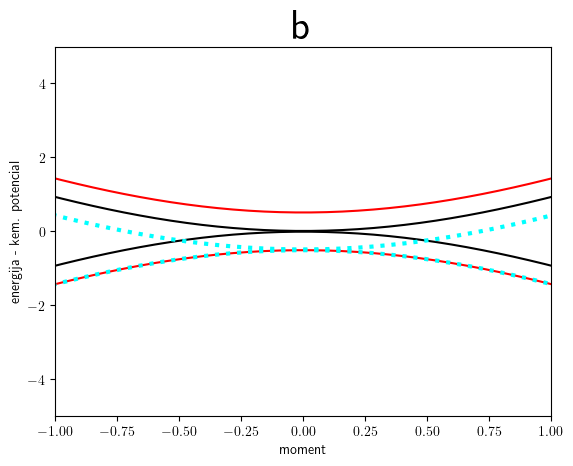

In [369]:
# example (b)
t = 1
t_ = 1.*t
t12 = 0
epsilon = 2.01*t
Vb = 0.5*t
Vc = 0.5*t

phys_parameters = {'b': b,
                   't': t,
                    't_': t_,
                    't12': t12,
                    'epsilon': epsilon,
                    'Vb': Vb,
                    'Vc': Vc}

mu0 = 0.
include_hartree = True
mu0 = find_GS_mu(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()

phys_parameters0 = {'b': b,
                   't': t,
                    't_': t_,
                    't12':0,
                    'epsilon': epsilon,
                    'Vb': 0,
                    'Vc': 0}
mu0 = 0.
include_hartree = True
mu0 = find_GS_mu(Nk, mu0, phys_parameters0, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m0 = model(Nk, mu0, phys_parameters0, parameters1, parameters2, include_hartree)
m0.GS()

plt.plot(m.K, m.energije[0] - m.mu, color='red')
plt.plot(m.K, m.energije[1] - m.mu, color='red')

plt.plot(m.K, m0.energije[0] - m0.mu, color='0')
plt.plot(m.K, m0.energije[1] - m0.mu, color='0')

plt.title('b', fontsize=30)
plt.ylim(-5,5)
plt.xlim(-1,1)

delta_k = -Vb/Nk * np.sum(m.rho[1,0,:]) - Vc/Nk * np.sum(m.rho[1,0,:] * np.exp(-1j*m.K)) * np.exp(-1j*m.K)
E_minus = (t-t_)*np.cos(m.K) - m.mu - np.sqrt(((t+t_)*np.cos(m.K) - epsilon)**2 + np.abs(delta_k)**2)
E_plus = (t-t_)*np.cos(m.K) - m.mu + np.sqrt(((t+t_)*np.cos(m.K) - epsilon)**2 + np.abs(delta_k)**2)
plt.plot(m.K, E_minus, ls='dotted', lw=3, color='cyan', label='EI faza, analiticno')
plt.plot(m.K, E_plus, ls='dotted', lw=3, color='cyan')

plt.xlabel('moment')
plt.ylabel('energija - kem. potencial')

In [379]:
omegas = np.linspace(-1,1,100)
res = Phit(m.K, m.rho, m.vecs, m.energije, phys_parameters, m.mu, omegas, 0.05)

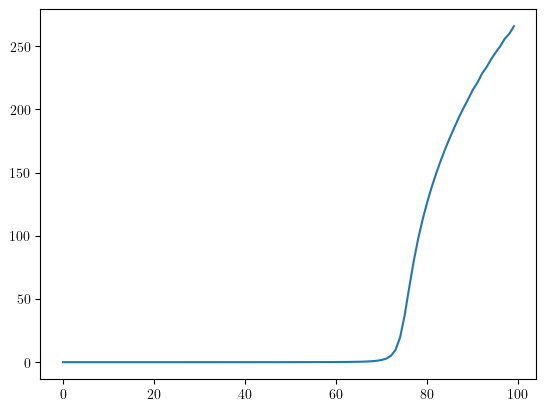

In [388]:
plt.plot(res[2].real)

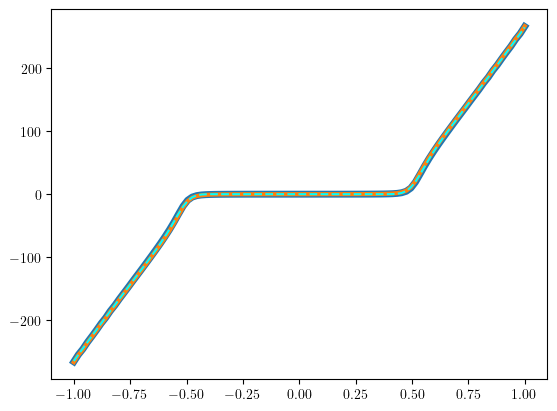

In [396]:
plt.plot(omegas, omegas * res[0].real, lw=5)
plt.plot(omegas, res[1].real + res[2].real, lw=3)


phi_boltz = Phi_boltz(m.K, m.energije, m.mu, omegas)

plt.plot(omegas, omegas * phi_boltz / (2*Gamma), color='cyan', ls='dashed')

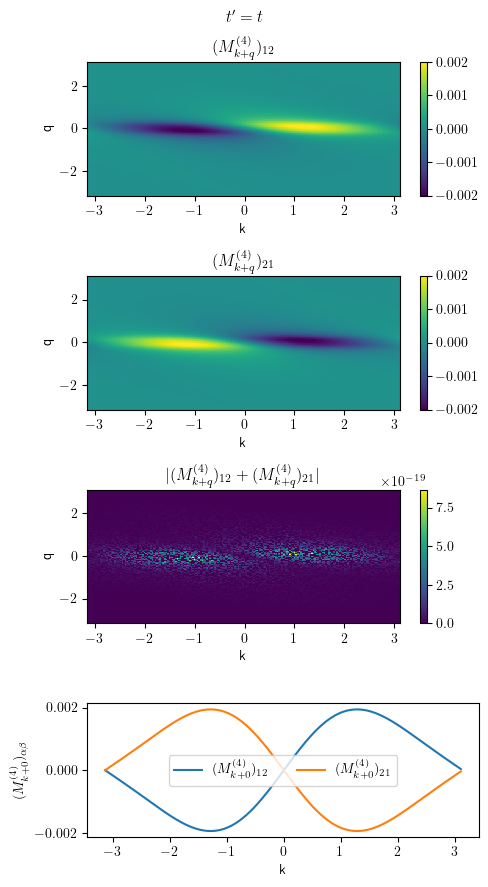

In [191]:
# cetrti prispevek
j, jK, jI = j_tok(m.K, phys_parameters, m.mu)
U = m.vecs
rho = m.rho

M_4 = - np.einsum('ijlkq, jlk-> ijkq', jI, rho)

fig, ax = plt.subplots(nrows=4, figsize=(5,9))

for ind in range(3):
    ax[ind].set_xlabel('k')
    ax[ind].set_ylabel('q')

im = ax[0].pcolormesh(m.K, m.K, M_4[0,1].real, vmin=-0.002, vmax=0.002)
fig.colorbar(im, ax=ax[0])
ax[0].set_title('$(M_{k+q}^{(4)})_{12}$')

im2 = ax[1].pcolormesh(m.K, m.K, M_4[1,0].real, vmin=-0.002, vmax=0.002)
fig.colorbar(im2, ax=ax[1])
ax[1].set_title('$(M_{k+q}^{(4)})_{21}$')

im3 = ax[2].pcolormesh(m.K, m.K, np.abs(M_4[1,0].real + M_4[0,1].real))
fig.colorbar(im3, ax=ax[2])
ax[2].set_title('$|(M_{k+q}^{(4)})_{12} + (M_{k+q}^{(4)})_{21} |$')

ax[3].plot(m.K, M_4[0,1, m.Nk//2].real, label='$(M_{k+0}^{(4)})_{12}$')
ax[3].plot(m.K, M_4[1,0, m.Nk//2].real, label='$(M_{k+0}^{(4)})_{21}$')
ax[3].legend(ncols=2)
ax[3].set_ylabel(r'$(M_{k+0}^{(4)})_{\alpha\beta}$')
ax[3].set_xlabel('k')

fig.suptitle(f"$t'=t$")
plt.tight_layout()

In [192]:
omegas = np.linspace(-3,3,100)
phi_4 = np.zeros((len(omegas), m.Nk, m.Nk), dtype='complex')
for i, omega in enumerate(omegas):
    print(i)
    for ii, k in enumerate(m.K):
        for iii, k in enumerate(m.K):
            ind = (ii + iii - m.Nk//2) % m.Nk
            matrix = U[:,:,ind] @ M_4[:,:,ii,iii] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]) @ U[:,:,ind] @ j[:,:,ind] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind])
            phi_4[i, ii, iii] = np.trace(U[:,:,ind] @ M_4[:,:,ii,iii] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]) @ U[:,:,ind] @ j[:,:,ind] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [197]:
np.allclose(np.einsum('ukq->u', phi_4), 0)

True

True


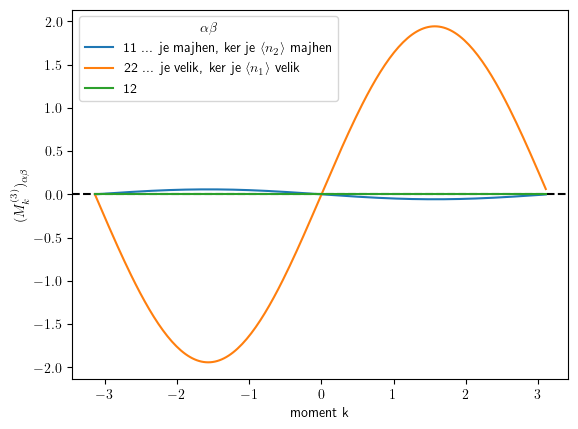

In [17]:
j, jK, jI = j_tok(m.K, phys_parameters, m.mu)
U = m.vecs
rho = m.rho

# prvi in drugi prispevek sta enaka nic, saj velja:
print(np.allclose(np.einsum('ijk,ijk->', j, rho), 0))

# tretji prispevek
M_3 = np.einsum('acbk, ccu-> abk', jI[:,:,:,:,m.Nk//2], rho)
plt.plot(m.K, M_3[0,0].real, label=r'11 ... je majhen, ker je $\expval{n_2}$ majhen')
plt.plot(m.K, M_3[1,1].real, label=r'22 ... je velik, ker je $\expval{n_1}$ velik')
plt.plot(m.K, M_3[0,1].real, label='12')
plt.xlabel('moment k')
plt.ylabel(r'$(M_k^{(3)})_{\alpha\beta}$')
plt.legend().set_title(r'$\alpha\beta$')
plt.axhline(0, color='0', ls='dashed', zorder=-1000)
plt.show()

# cetrti prispevek
M_4 = - np.einsum('ijlkq, jlk->ijkq', jI, rho)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


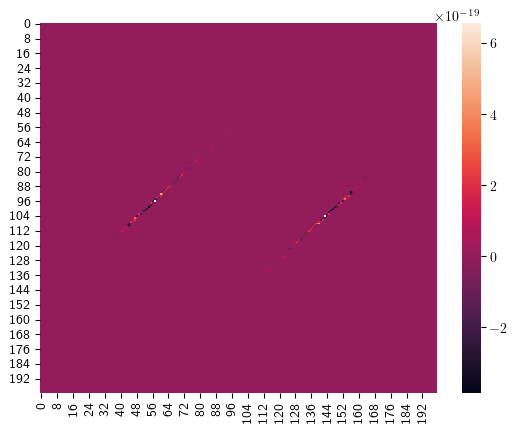

True


In [18]:
omegas = np.linspace(-3,3,100)
phi_4 = np.zeros((len(omegas), m.Nk, m.Nk), dtype='complex')
for i, omega in enumerate(omegas):
    print(i)
    for ii, k in enumerate(m.K):
        for iii, k in enumerate(m.K):
            ind = (ii + iii - m.Nk//2) % m.Nk
            matrix = U[:,:,ind] @ M_4[:,:,ii,iii] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]) @ U[:,:,ind] @ j[:,:,ind] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind])
            phi_4[i, ii, iii] = np.trace(U[:,:,ind] @ M_4[:,:,ii,iii] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]) @ U[:,:,ind] @ j[:,:,ind] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]))

sns.heatmap(phi_4[80].real)
plt.show()
np.einsum('ijk->i', phi_4)

# peti prispevek -> je nic
M_5 = np.diag(np.einsum('ijlk,ilk->j', jI[:,:,:,:,m.Nk//2], rho))
print(np.allclose(M_5, 0))

# sesti prispevek

M_6 = np.zeros((2,2,m.Nk), dtype='complex')
for i, k in enumerate(m.K):
    for ii, q in enumerate(m.K):
        ind = (ii + iii - m.Nk//2) % m.Nk
        M_6[:,:,i] += np.einsum('ijl,ij->jl', jI[:,:,:,i,ii], rho[:,:,ind])

phi_6 = np.zeros(len(omegas), dtype='complex')
for i, omega in enumerate(omegas):
    for jj, k in enumerate(m.K):
        phi_6[i] = np.trace(U[:,:,jj] @ M_6[:,:,jj] @ U[:,:,jj].conj().T @ spektralna_k(omega, m.mu, m.energije[:,jj]) @ U[:,:,jj] @ j[:,:,jj] @ U[:,:,jj].conj().T @ spektralna_k(omega, m.mu, m.energije[:,jj]))
        

/var/folders/pm/d_9cvb8n3xlftb1wrgw8y4dr0000gq/T/ipykernel_5207/1586372522.py:43: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,i], 1/(1 + np.exp((en - mu)/T)))
/var/folders/pm/d_9cvb8n3xlftb1wrgw8y4dr0000gq/T/ipykernel_5207/1586372522.py:55: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,i], 1/(1 + np.exp((en - mu)/T)))
/var/folders/pm/d_9cvb8n3xlftb1wrgw8y4dr0000gq/T/ipykernel_5207/1586372522.py:56: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,-i], 1/(1 + np.exp((en - mu)/T)))


found mu in the Ground state
found mu in the Ground state


Text(0, 0.5, 'energija - kem. potencial')

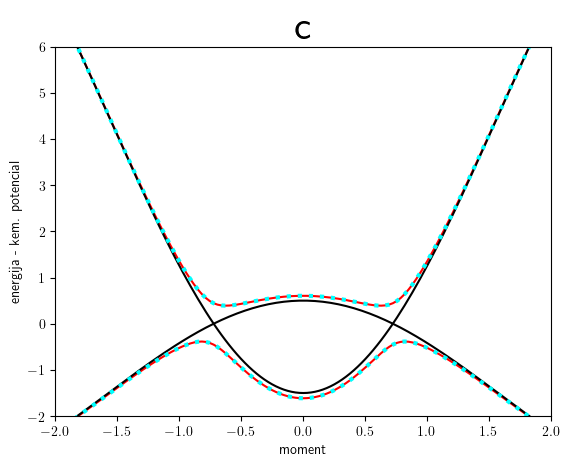

In [19]:
# example (c)
t = 1
t_ = 3.*t
epsilon = 3*t
Vb = 2*t
Vc = 2*t

phys_parameters = {'b': b,
                   't': t,
                    't_': t_,
                    'epsilon': epsilon,
                    'Vb': Vb,
                    'Vc': Vc}

mu0 = 0.
include_hartree = False
mu0 = find_GS_mu(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()

phys_parameters0 = {'b': b,
                   't': t,
                    't_': t_,
                    'epsilon': epsilon,
                    'Vb': 0,
                    'Vc': 0}
mu0 = 0.
include_hartree = False
mu0 = find_GS_mu(Nk, mu0, phys_parameters0, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m0 = model(Nk, mu0, phys_parameters0, parameters1, parameters2, include_hartree)
m0.GS()

plt.plot(m.K, m.energije[0] - m.mu, color='red')
plt.plot(m.K, m.energije[1] - m.mu, color='red')

plt.plot(m.K, m0.energije[0] - m0.mu, color='0')
plt.plot(m.K, m0.energije[1] - m0.mu, color='0')

plt.title('c', fontsize=30)
plt.ylim(-2,6)
plt.xlim(-2,2)

delta_k = -Vb/Nk * np.sum(m.rho[1,0,:]) - Vc/Nk * np.sum(m.rho[1,0,:] * np.exp(-1j*m.K)) * np.exp(-1j*m.K)
E_minus = (t-t_)*np.cos(m.K) - m.mu - np.sqrt(((t+t_)*np.cos(m.K) - epsilon)**2 + np.abs(delta_k)**2)
E_plus = (t-t_)*np.cos(m.K) - m.mu + np.sqrt(((t+t_)*np.cos(m.K) - epsilon)**2 + np.abs(delta_k)**2)
plt.plot(m.K, E_minus, ls='dotted', lw=3, color='cyan', label='EI faza, analiticno')
plt.plot(m.K, E_plus, ls='dotted', lw=3, color='cyan')

plt.xlabel('moment')
plt.ylabel('energija - kem. potencial')

True


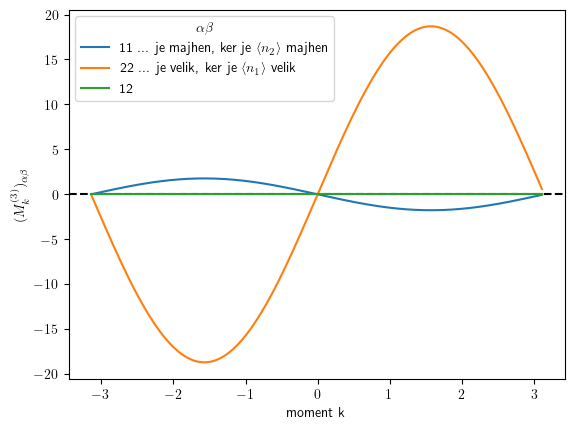

In [20]:
j, jK, jI = j_tok(m.K, phys_parameters, m.mu)
U = m.vecs
rho = m.rho

# prvi in drugi prispevek sta enaka nic, saj velja:
print(np.allclose(np.einsum('ijk,ijk->', j, rho), 0))

# tretji prispevek
M_3 = np.einsum('acbk, ccu-> abk', jI[:,:,:,:,m.Nk//2], rho)
plt.plot(m.K, M_3[0,0].real, label=r'11 ... je majhen, ker je $\expval{n_2}$ majhen')
plt.plot(m.K, M_3[1,1].real, label=r'22 ... je velik, ker je $\expval{n_1}$ velik')
plt.plot(m.K, M_3[0,1].real, label='12')
plt.xlabel('moment k')
plt.ylabel(r'$(M_k^{(3)})_{\alpha\beta}$')
plt.legend().set_title(r'$\alpha\beta$')
plt.axhline(0, color='0', ls='dashed', zorder=-1000)
plt.show()

# cetrti prispevek
M_4 = - np.einsum('ijlkq, jlk->ijkq', jI, rho)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


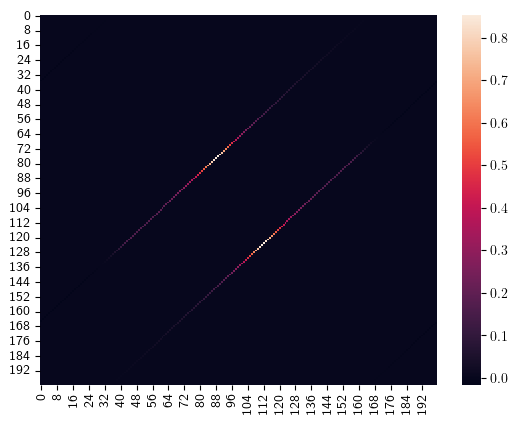

True


In [21]:
omegas = np.linspace(-3,3,100)
phi_4 = np.zeros((len(omegas), m.Nk, m.Nk), dtype='complex')
for i, omega in enumerate(omegas):
    print(i)
    for ii, k in enumerate(m.K):
        for iii, k in enumerate(m.K):
            ind = (ii + iii - m.Nk//2) % m.Nk
            matrix = U[:,:,ind] @ M_4[:,:,ii,iii] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]) @ U[:,:,ind] @ j[:,:,ind] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind])
            phi_4[i, ii, iii] = np.trace(U[:,:,ind] @ M_4[:,:,ii,iii] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]) @ U[:,:,ind] @ j[:,:,ind] @ U[:,:,ind].conj().T @ spektralna_k(omega, m.mu, m.energije[:,ind]))

sns.heatmap(phi_4[80].real)
plt.show()
np.einsum('ijk->i', phi_4)

# peti prispevek -> je nic
M_5 = np.diag(np.einsum('ijlk,ilk->j', jI[:,:,:,:,m.Nk//2], rho))
print(np.allclose(M_5, 0))

# sesti prispevek

M_6 = np.zeros((2,2,m.Nk), dtype='complex')
for i, k in enumerate(m.K):
    for ii, q in enumerate(m.K):
        ind = (ii + iii - m.Nk//2) % m.Nk
        M_6[:,:,i] += np.einsum('ijl,ij->jl', jI[:,:,:,i,ii], rho[:,:,ind])

phi_6 = np.zeros(len(omegas), dtype='complex')
for i, omega in enumerate(omegas):
    for jj, k in enumerate(m.K):
        phi_6[i] = np.trace(U[:,:,jj] @ M_6[:,:,jj] @ U[:,:,jj].conj().T @ spektralna_k(omega, m.mu, m.energije[:,jj]) @ U[:,:,jj] @ j[:,:,jj] @ U[:,:,jj].conj().T @ spektralna_k(omega, m.mu, m.energije[:,jj]))
        

In [35]:
j, jK, jI = j_tok(m.K, phys_parameters, m.mu)
U = m.vecs
rho = m.rho

matrix = np.einsum('ijlk,ilk->jk', jI[:,:,:,:,m.Nk//2], rho)
matrix[0]

array([-2.11442035e-34+6.20012103e-60j, -1.08964826e-09+9.23082177e-28j,
       -8.72546706e-09+1.02241528e-24j, -2.94951224e-08+1.58273821e-23j,
       -7.00696948e-08+2.05310071e-23j, -1.37246453e-07+4.44010449e-23j,
       -2.37992923e-07-1.90975736e-23j, -3.79492724e-07+2.57202884e-23j,
       -5.69193654e-07-7.19603880e-23j, -8.14858560e-07-2.45360584e-24j,
       -1.12461957e-06-1.07702812e-22j, -1.50703630e-06+1.96652276e-22j,
       -1.97115875e-06-6.19035559e-23j, -2.52659569e-06-2.91992970e-22j,
       -3.18358931e-06+1.39422081e-22j, -3.95309725e-06-3.38640612e-22j,
       -4.84688303e-06+7.51192871e-23j, -5.87761619e-06+5.20812919e-22j,
       -7.05898364e-06-8.76852314e-23j, -8.40581377e-06-2.05114068e-23j,
       -9.93421542e-06+6.18324872e-22j, -1.16617339e-05+3.52367246e-22j,
       -1.36075264e-05-5.24666387e-22j, -1.57925607e-05-7.58666552e-23j,
       -1.82398391e-05-3.67067000e-22j, -2.09746539e-05+1.02581098e-21j,
       -2.40248772e-05+1.03964590e-21j, -2.74212924

/opt/anaconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


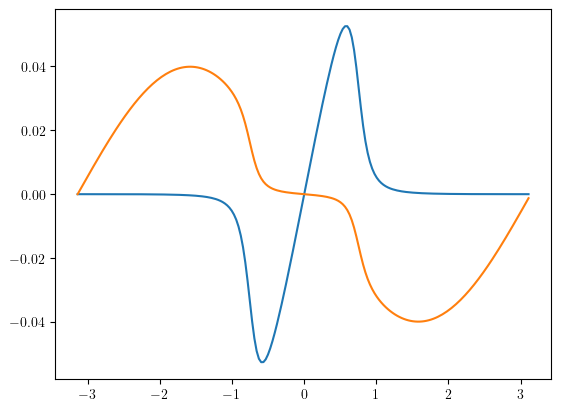

In [38]:
plt.plot(m.K, matrix[0])
plt.plot(m.K, matrix[1])

/var/folders/pm/d_9cvb8n3xlftb1wrgw8y4dr0000gq/T/ipykernel_3131/1774762832.py:43: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,i], 1/(1 + np.exp((en - mu)/T)))
/var/folders/pm/d_9cvb8n3xlftb1wrgw8y4dr0000gq/T/ipykernel_3131/1774762832.py:55: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,i], 1/(1 + np.exp((en - mu)/T)))
/var/folders/pm/d_9cvb8n3xlftb1wrgw8y4dr0000gq/T/ipykernel_3131/1774762832.py:56: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,-i], 1/(1 + np.exp((en - mu)/T)))


found mu in the Ground state
found mu in the Ground state


Text(0, 0.5, 'energija - kem. potencial')

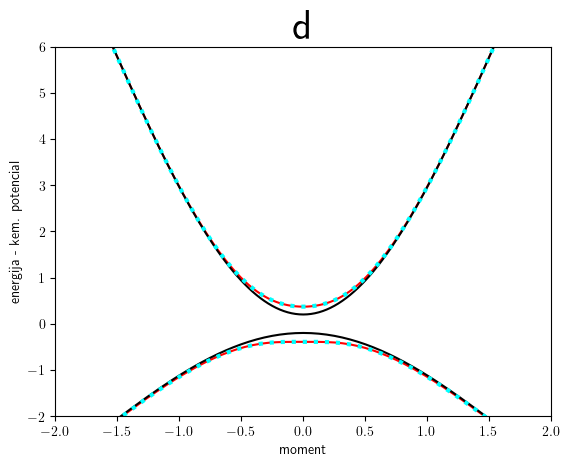

In [139]:
# example (d)
t = 1
t_ = 3.*t
epsilon = 4.2*t
Vb = 2*t
Vc = 2*t

phys_parameters = {'b': b,
                   't': t,
                    't_': t_,
                    'epsilon': epsilon,
                    'Vb': Vb,
                    'Vc': Vc}

mu0 = 0.
include_hartree = False
mu0 = find_GS_mu(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()

phys_parameters = {'b': b,
                   't': t,
                    't_': t_,
                    'epsilon': epsilon,
                    'Vb': 0,
                    'Vc': 0}
mu0 = 0.
include_hartree = False
mu0 = find_GS_mu(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m0 = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m0.GS()

plt.plot(m.K, m.energije[0] - m.mu, color='red')
plt.plot(m.K, m.energije[1] - m.mu, color='red')

plt.plot(m.K, m0.energije[0] - m0.mu, color='0')
plt.plot(m.K, m0.energije[1] - m0.mu, color='0')

plt.title('d', fontsize=30)
plt.ylim(-2,6)
plt.xlim(-2,2)

delta_k = -Vb/Nk * np.sum(m.rho[1,0,:]) - Vc/Nk * np.sum(m.rho[1,0,:] * np.exp(-1j*m.K)) * np.exp(-1j*m.K)
E_minus = (t-t_)*np.cos(m.K) - m.mu - np.sqrt(((t+t_)*np.cos(m.K) - epsilon)**2 + np.abs(delta_k)**2)
E_plus = (t-t_)*np.cos(m.K) - m.mu + np.sqrt(((t+t_)*np.cos(m.K) - epsilon)**2 + np.abs(delta_k)**2)
plt.plot(m.K, E_minus, ls='dotted', lw=3, color='cyan', label='EI faza, analiticno')
plt.plot(m.K, E_plus, ls='dotted', lw=3, color='cyan')

plt.xlabel('moment')
plt.ylabel('energija - kem. potencial')

-4.147074678794456

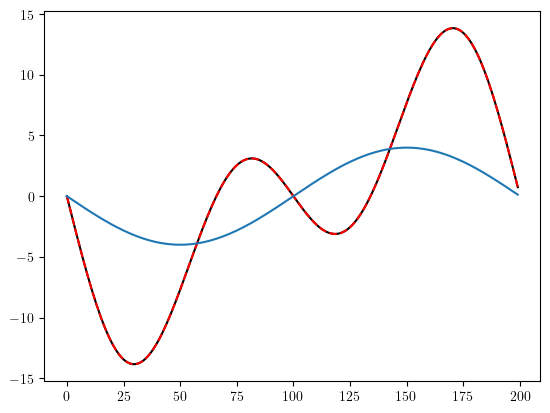

In [667]:
#plt.plot(matrika1[1,1].real)
#plt.plot(matrika1[0,0].real)



#plt.plot(2*t_*a*(Vb+Vc)*np.sin(m.K * a) * n_1 / m.Nk, ls='dashed')
#plt.plot(-2*t*a*(Vb+Vc)*np.sin(m.K * a) * n_2 / m.Nk, ls='dashed')


plt.plot(J_K[1,1].real, color='black')
plt.plot(2*t_ * np.sin(m.K) * (-2*t_*np.cos(m.K) + epsilon - m.mu), color='red', ls='dashed')
plt.plot(J[1,1].real)


t_*(-2*t_+epsilon-m.mu)

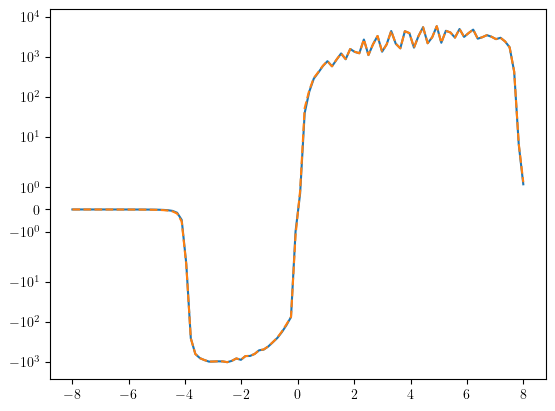

In [677]:
plt.plot(omegas, phi_I.real + phi_K.real)
plt.plot(omegas, phi.real * omegas, ls='dashed')


plt.yscale('symlog')

In [541]:
xi_k = 0.5*((-2*t_*np.cos(k*a) + epsilon) - (2*t*np.cos(k*a) - epsilon))
delta_k = - 1/m.Nk * Vb * np.sum(m.rho[1,0,:]) - 1/m.Nk * Vc * np.sum(m.rho[1,0,:] * np.exp(-1j*K*a)) * np.exp(-1j*k*a)


c:\Users\anast\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\anast\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


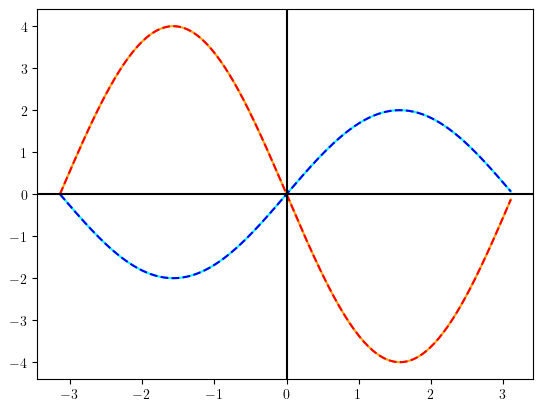

In [561]:

plt.plot(m.K, np.einsum('ijk,jlk,mlk->imk', m.vecs, J, m.vecs.conj())[0,0], color='cyan')

plt.plot(m.K, np.einsum('ijk,jlk,mlk->imk', m.vecs, J, m.vecs.conj())[1,1], color='orange')

plt.plot(m.K, J[1,1].real, ls='dashed', color='red')
plt.plot(m.K, J[0,0].real, ls='dashed', color='blue')

#plt.plot(m.K, -J_K[1,1].real, color='red')
#plt.plot(m.K, -J_K[0,0].real, color='blue')

#plt.plot(m.K, -2*a*t*np.sin(m.K*a) * (2*t*np.cos(m.K*a) - epsilon - m.mu), ls='dashed')
#plt.plot(m.K, 2*a*t_*np.sin(m.K*a) * (-2*t_*np.cos(m.K*a) + epsilon - m.mu), ls='dashed')

plt.axhline(0, color='black')
plt.axvline(0, color='black')




In [531]:
np.max(np.abs(m.vecs[1,0]))

1.5047807951396032e-07